## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
AUTHOR  = 'A.Anand '                                                            
FIT     = 'NMF     '                                                            
SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 
TGTQSO  = 'DESI DR1'                                                            

In [3]:
hdul.close()

### Running qsoabsfind as bash script:

In [4]:
# #!/bin/bash

# # Loop over absorber types
# for absorber in MgII CIV; do
#   echo "Running qsoabsfind for $absorber..."

#   qsoabsfind \
#     --input-fits-file ../data/desi/qso_test_spectra.fits \
#     --absorber ${absorber} \
#     --output ../data/desi/${absorber}_cat.fits \
#     --headers AUTHOR=A.Anand SURVEY=DESI DR=1 \
#     --ncpus 8 \
#     --coldens \
#     --dv 300 \
#     --constant-file ../data/desi/desi_constants.py \
#     >> ../data/desi/logs/${absorber}.log

#   echo "Finished $absorber"
# done


- I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits` and `../data/desi/CIV_cat.fits`.

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/desi/MgII_cat.fits
  ABSORBER: 34 rows
  METADATA: 34 rows
  COLUMN_DENSITY: 34 rows
INFO: Time taken to read catalog from ../data/desi/MgII_cat.fits 0.03 seconds


Text(0.5, 0, 'MgII redshift')

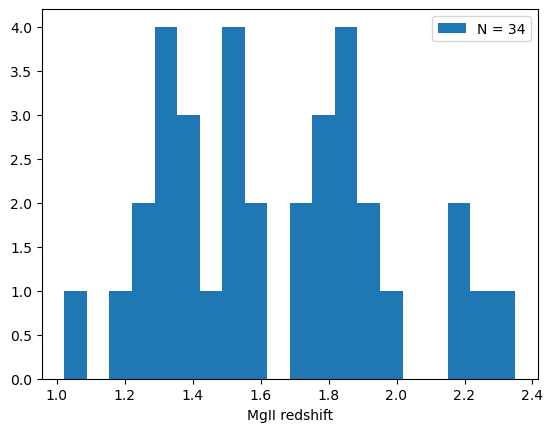

In [5]:
from qsoabsfind.spec import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits')
mgii_tab.read_catalog()
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

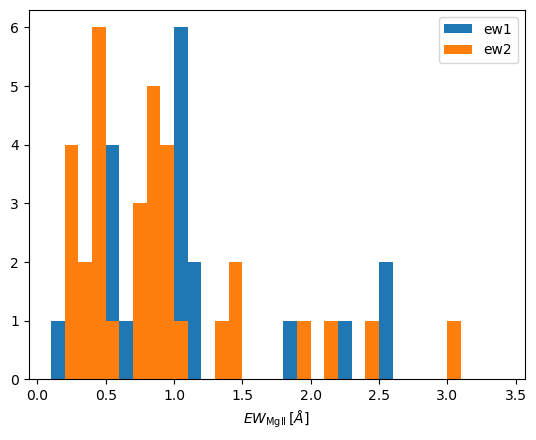

In [6]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 7...
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.01 seconds


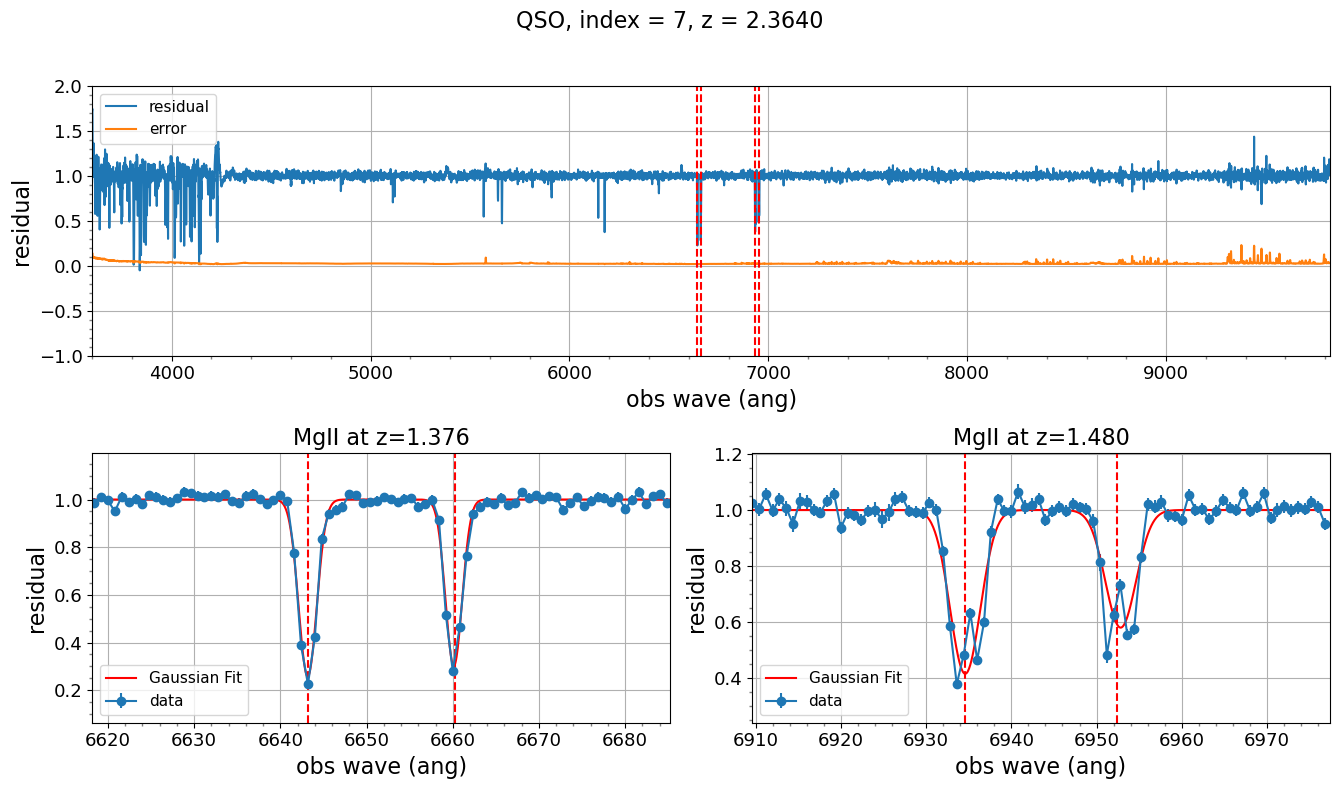

In [7]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [8]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII).
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
  

In [9]:
parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)


INFO: Starting search for QSO INDEX = 7
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.01 seconds
INFO: using default wavelength search window
INFO: wavelength search window in quasar-rest frame: (1549.48, 2799.117) Angstroms
INFO: final wave window selection for MgII took 0.00 seconds
INFO: search absorber = MgII
INFO: Z_QSO = 2.363953848604629
INFO: For MgII, theoretical oscillator strength ratio: 1.999784031677045
INFO: instrumental resolution will be calculated from wavelength array, it is assumed that wavelength pixels are less than FWHM, so will not divide by 2.355
INFO: mean wave_resolution = 0.80000, mean resolution per pixel  = 38.685 [km/s], del_sigma: 0.36083601478439187
INFO: convolving for kernel width: 0.46005593889387925 Angstrom.
INFO: sigma cut on convolved flux for potential candidates...
INFO: convolving for kernel width: 0.6134079185251723 Angstrom.
INFO: sigma cut on convolved flux for potential candidates...
INFO: convolving for kernel width: 0.766

/global/homes/a/abhijeet/software/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))


INFO: QSO_INDEX = 7, Condition checks for Z_ABS = [1.38876257]:
INFO: gaussian_parameters > bound[0] + 0.001: [3.82955533e-02 2.79630844e+03 3.52137690e-01 2.52177332e-02
 2.80295066e+03 6.27609586e-01] > [2.10000000e-02 2.79575100e+03 2.61836015e-01 2.10000000e-02
 2.80292100e+03 2.61836015e-01]: True
INFO: gaussian_parameters < bound[0] - 0.001: [3.82955533e-02 2.79630844e+03 3.52137690e-01 2.52177332e-02
 2.80295066e+03 6.27609586e-01] < [1.10900000e+00 2.79694900e+03 1.09240804e+01 1.10900000e+00
 2.80411900e+03 1.09240804e+01]: True
INFO: lower_del_lam <= c1 - c0 <= upper_del_lam: 6.570000000000073 <= 6.642217373307631 <= 7.770000000000072: True
INFO: sn1 >= sn_line1: -0.010815932082462723 >= 3: False
INFO: sn2 >= sn_line2: 0.20807701280346563 >= 2: False
INFO: vel1 >=0: 11.666695623515093 >= 0: True
INFO: vel2 >=0: 56.77086559440755 >= 0: True
INFO: min_dr < dr < max_dr: 0.9102692157030106 < 0.8520503640174866 < 2.0895148159740344: False
INFO: ew1_snr > 1: 14.802806854248047 > 1:

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


([7, 7],
 [1.3756580423999458, 1.479874541940378],
 [[0.7418906589274109,
   2796.3507939994006,
   0.4419697698695962,
   0.6973268143549871,
   2803.4852104337047,
   0.4045477165374893],
  [0.5851813246617904,
   2796.3490267050147,
   0.7138210771069022,
   0.4203045004315297,
   2803.7000467674984,
   0.7231053357403721]],
 [[0.010620877044293625,
   0.0083778686589199,
   0.008902473400284794,
   0.011525881635357631,
   0.008707516574032993,
   0.009193385975471589],
  [0.010815931025005734,
   0.015987169987328,
   0.01702228115936211,
   0.013063111342647036,
   0.02875689547228986,
   0.028189156886787785]],
 [0.8219064474105835, 1.0470556020736694],
 [0.7071247696876526, 0.7618255615234375],
 [1.5290312767028809, 1.808881163597107],
 [0.004789052065461874, 0.005616054404526949],
 [0.004381650127470493, 0.006020981352776289],
 [0.006491061300039291, 0.008233606815338135],
 [5.127139957039617e-06, 1.4608302990382072e-05],
 [56.87292429695787, 43.36498558787063],
 [48.320784295

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/desi/CIV_cat.fits
  ABSORBER: 8 rows
  METADATA: 8 rows
  COLUMN_DENSITY: 8 rows
INFO: Time taken to read catalog from ../data/desi/CIV_cat.fits 0.03 seconds


Text(0.5, 0, 'CIV redshift')

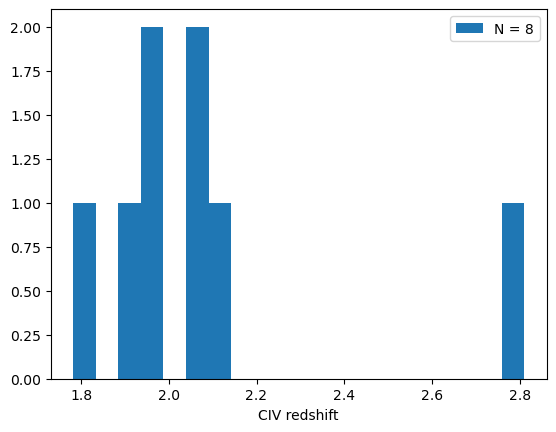

In [10]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits')
civ_tab.read_catalog()
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.01 seconds
INFO: plotting CIV for QSO INDEX = 90...


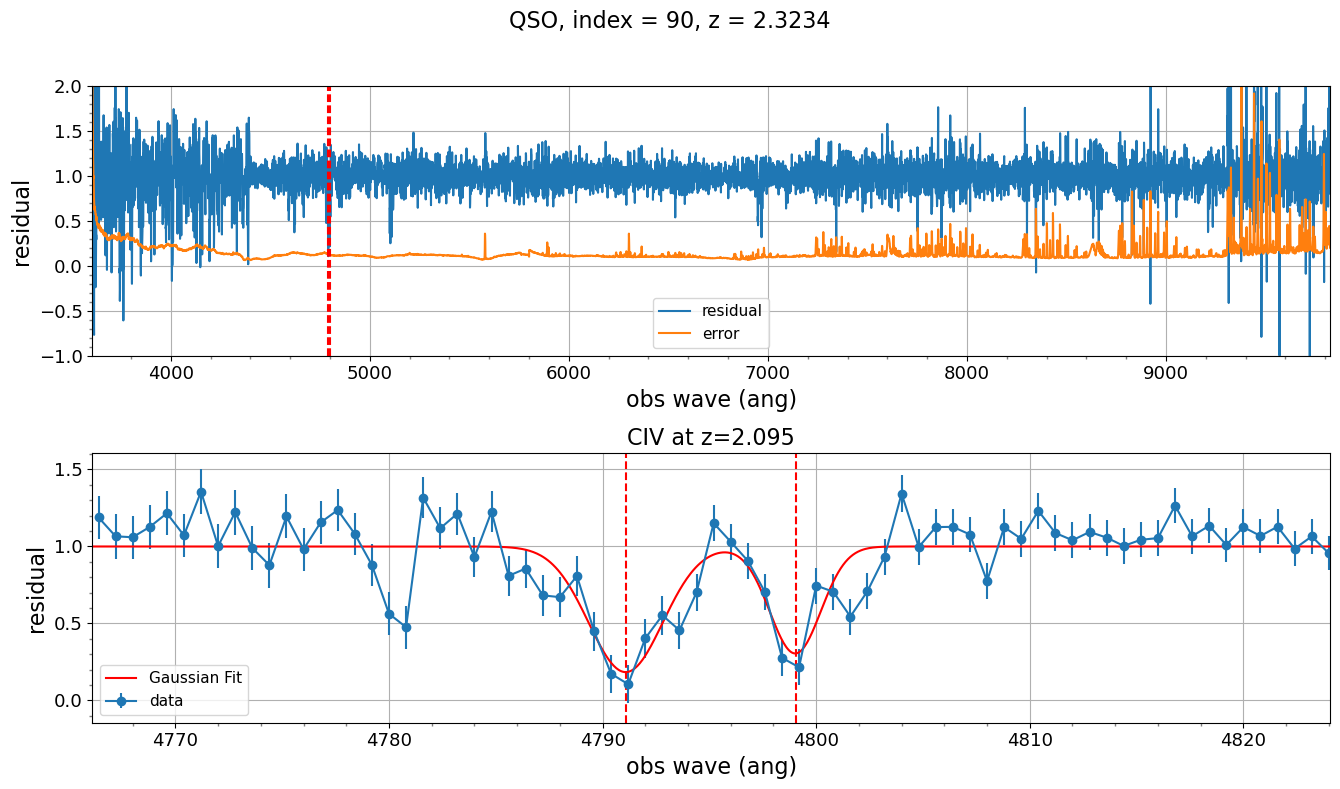

In [12]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
# select corresponding zabs table
zabs = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)